In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_primary = pd.read_csv('krisha_primary_almaty_cleaned.csv')
df_primary.head(10)

,price,rooms,area_m2,district,title,description,link,page,price_per_m2,price_segment
0,17787000,1,36.30,NaN,1-комнатная квартира · 36.3 м²,"жил. комплекс Dostar, 9 этажей, 2026 г.п., пот...",https://krisha.kz/a/show/673332516,1,4.900000e+05,cheap
1,17600250,1,37.85,NaN,1-комнатная квартира · 37.85 м²,"жил. комплекс Keruen, 6 этажей, 2025 г.п., пот...",https://krisha.kz/a/show/1000459786,1,4.650000e+05,cheap
2,67440000,1,58.30,NaN,1-комнатная квартира · 58.3 м²,"жил. комплекс Etasa Residence, 18 этажей, 2023...",https://krisha.kz/a/show/684354905,1,1.156775e+06,expensive
3,128359000,2,77.00,NaN,2-комнатная квартира · 77 м²,"жил. комплекс Diamond, 9 этажей, 2028 г.п., по...",https://krisha.kz/a/show/1008497882,1,1.667000e+06,expensive
4,29216000,2,53.12,NaN,2-комнатная квартира · 53.12 м²,"жил. комплекс Аккент, 12 этажей, 2023 г.п., по...",https://krisha.kz/a/show/1008768026,1,5.500000e+05,cheap
5,35043750,3,78.75,NaN,3-комнатная квартира · 78.75 м²,"жил. комплекс Keruen, 6 этажей, 2025 г.п., пот...",https://krisha.kz/a/show/1000459789,1,4.450000e+05,cheap
6,36045000,2,66.75,NaN,2-комнатная квартира · 66.75 м²,"жил. комплекс Аккент, 12 этажей, 2023 г.п., по...",https://krisha.kz/a/show/1008768030,1,5.400000e+05,cheap
7,43260000,1,61.80,NaN,1-комнатная квартира · 61.8 м²,"жил. комплекс 7Su Nury, 10 этажей, 2025 г.п., ...",https://krisha.kz/a/show/1003290032,1,7.000000e+05,medium
8,68595000,2,80.70,NaN,2-комнатная квартира · 80.7 м²,"жил. комплекс Apple Residence, 12 этажей, 2024...",https://krisha.kz/a/show/677333170,1,8.500000e+05,medium
9,35893800,2,66.47,NaN,2-комнатная квартира · 66.47 м²,"жил. комплекс Аккент, 12 этажей, 2023 г.п., по...",https://krisha.kz/a/show/1008768028,1,5.400000e+05,cheap


In [3]:
df_secondary = pd.read_csv('krisha_secondary_almaty_cleaned.csv')
df_secondary.head(10)

,price,rooms,area_m2,district,title,description,link,page,price_per_m2,price_segment
0,155000000,4,153.00,NaN,4-комнатная квартира · 153 м² · 8/9 этаж,"монолитный дом, 2003 г.п., потолки 3м., санузе...",https://krisha.kz/a/show/761623800,1,1.013072e+06,expensive
1,106000000,3,150.00,NaN,3-комнатная квартира · 150 м² · 4/10 этаж,"жил. комплекс Коктем по Тимирязева-Шашкина, мо...",https://krisha.kz/a/show/1009843904,1,7.066667e+05,medium
2,70587000,4,102.30,NaN,4-комнатная квартира · 102.3 м²,"жил. комплекс Dream City. Art, 6 этажей, 2026 ...",https://krisha.kz/a/show/1009995074,1,6.900000e+05,cheap
3,45647000,3,65.21,NaN,3-комнатная квартира · 65.21 м²,"жил. комплекс Maxima City, 9 этажей, 2025 г.п....",https://krisha.kz/a/show/688265083,1,7.000000e+05,medium
4,57742809,3,81.98,NaN,3-комнатная квартира · 81.98 м²,"жил. комплекс Dream City. Eco, 6 этажей, 2025 ...",https://krisha.kz/a/show/694706344,1,7.043524e+05,medium
5,75000000,2,66.00,NaN,2-комнатная квартира · 66 м² · 6/9 этаж,"жил. комплекс TAYMAS, монолитный дом, 2025 г.п...",https://krisha.kz/a/show/1010882080,1,1.136364e+06,expensive
6,44569500,2,64.50,NaN,2-комнатная квартира · 64.5 м²,"жил. комплекс Dream City. Family, 6 этажей, 20...",https://krisha.kz/a/show/694704254,1,6.910000e+05,cheap
7,48490000,3,74.60,NaN,3-комнатная квартира · 74.6 м²,"жил. комплекс Kamenka Park, 3 этажа, 2024 г.п....",https://krisha.kz/a/show/682828219,1,6.500000e+05,cheap
8,30000000,2,65.50,NaN,2-комнатная квартира · 65.5 м²,"жил. комплекс Gate City, 9 этажей, 2023 г.п., ...",https://krisha.kz/a/show/682004958,1,4.580153e+05,cheap
9,48560160,2,64.65,NaN,2-комнатная квартира · 64.65 м²,"жил. комплекс Dream City. Family, 6 этажей, 20...",https://krisha.kz/a/show/694704255,1,7.511239e+05,medium


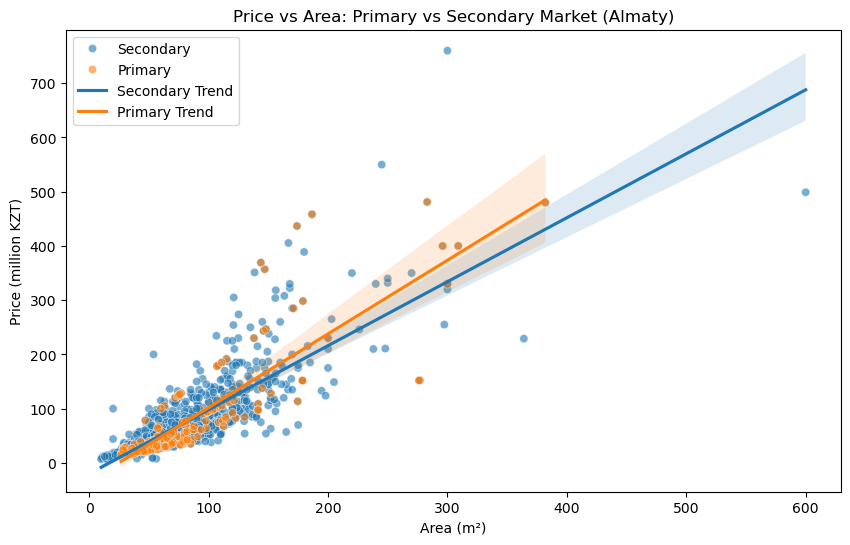

In [20]:
# adding "market" column
df_secondary["market"] = "Secondary"
df_primary["market"] = "Primary"

# joining
df_all = pd.concat([df_secondary, df_primary])

# in millions for better reading
df_all["price_mln"] = df_all["price"] / 1_000_000

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_all,
    x="area_m2",
    y="price_mln",
    hue="market",
    alpha=0.6
)

# trendlines for each market
sns.regplot(
    data=df_secondary,
    x="area_m2",
    y=df_secondary["price"] / 1_000_000,
    scatter=False,
    label="Secondary Trend",
)

sns.regplot(
    data=df_primary,
    x="area_m2",
    y=df_primary["price"] / 1_000_000,
    scatter=False,
    label="Primary Trend",
)

plt.title("Price vs Area: Primary vs Secondary Market (Almaty)")
plt.xlabel("Area (m²)")
plt.ylabel("Price (million KZT)")

# removing grid for cleaner look
plt.grid(False)

plt.savefig("scatter_price_area.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.show()

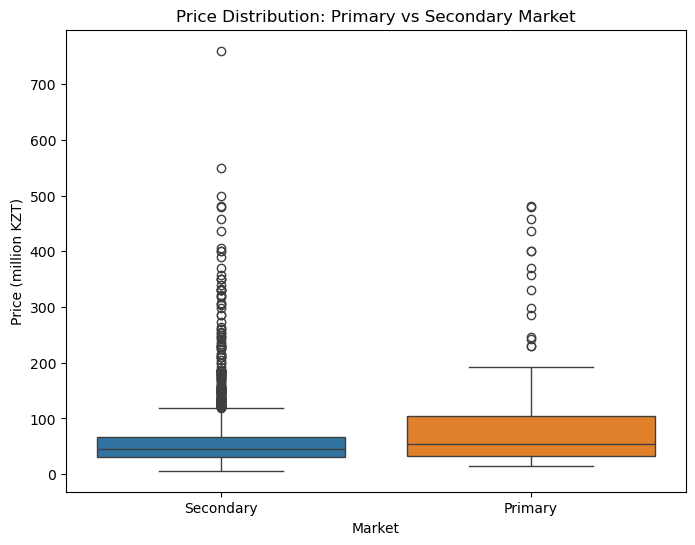

In [19]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_all,
    x="market",
    y="price_mln",
    hue="market"
)

plt.title("Price Distribution: Primary vs Secondary Market")
plt.xlabel("Market")
plt.ylabel("Price (million KZT)")

plt.grid(False)

plt.savefig("boxplot_price_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [9]:
df_all.to_csv("krisha_combined_almaty.csv", index=False)

In [11]:
df_all.info()
df_all.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2146 entries, 0 to 145
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          2146 non-null   int64  
 1   rooms          2146 non-null   int64  
 2   area_m2        2146 non-null   float64
 3   district       20 non-null     object 
 4   title          2146 non-null   object 
 5   description    2146 non-null   object 
 6   link           2146 non-null   object 
 7   page           2146 non-null   int64  
 8   price_per_m2   2146 non-null   float64
 9   price_segment  2146 non-null   object 
 10  market         2146 non-null   object 
 11  price_mln      2146 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 218.0+ KB


,price,rooms,area_m2,district,title,description,link,page,price_per_m2,price_segment,market,price_mln
0,155000000,4,153.00,NaN,4-комнатная квартира · 153 м² · 8/9 этаж,"монолитный дом, 2003 г.п., потолки 3м., санузе...",https://krisha.kz/a/show/761623800,1,1.013072e+06,expensive,Secondary,155.000000
1,106000000,3,150.00,NaN,3-комнатная квартира · 150 м² · 4/10 этаж,"жил. комплекс Коктем по Тимирязева-Шашкина, мо...",https://krisha.kz/a/show/1009843904,1,7.066667e+05,medium,Secondary,106.000000
2,70587000,4,102.30,NaN,4-комнатная квартира · 102.3 м²,"жил. комплекс Dream City. Art, 6 этажей, 2026 ...",https://krisha.kz/a/show/1009995074,1,6.900000e+05,cheap,Secondary,70.587000
3,45647000,3,65.21,NaN,3-комнатная квартира · 65.21 м²,"жил. комплекс Maxima City, 9 этажей, 2025 г.п....",https://krisha.kz/a/show/688265083,1,7.000000e+05,medium,Secondary,45.647000
4,57742809,3,81.98,NaN,3-комнатная квартира · 81.98 м²,"жил. комплекс Dream City. Eco, 6 этажей, 2025 ...",https://krisha.kz/a/show/694706344,1,7.043524e+05,medium,Secondary,57.742809


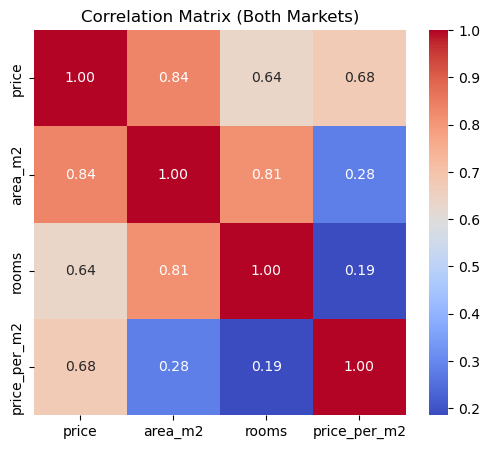

In [21]:
corr = df_all[["price", "area_m2", "rooms", "price_per_m2"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix (Both Markets)")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()